In [1]:
import os
import pandas as pd
import datetime as dt
import time
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

# Phase 0 - Constants and Functions

In [2]:
# Standardize the 'random_state' parameter across entire project
RND = 42

# Standardize which Scaler to use across the entire project
scaler = StandardScaler()

In [3]:
# function to determine if csv file path exists locally or not
def self_detect(dataset):
    """
    Used to self-detect the path of the dataset.csv file
    """

    tripleten_path = '/datasets/final_provider/'

    local_path = '/Users/georgeknight/Desktop/TripleTen_Projects/Sprint 17 - Final Project/datasets/final_provider'

    # check if the path exists, if not, use the local path
    if os.path.exists(tripleten_path):
        dataset_path = os.path.join(tripleten_path, dataset)
    else:
        dataset_path = os.path.join(local_path, dataset)

    return dataset_path

In [4]:
# function to loop over all categorical columns and calculate the churn rate
def churn_rate_by_category(df, column):
    """
    Calculates the churn rate based on a dataframe and a given column name.
    """

    summary = df_final.groupby(column)['Churned'].agg(['sum', 'count'])
    summary['churn_rate'] = round(summary['sum'] / summary['count'], 4)

    return summary

# Phase 1 - Load, Merge, Consolidate

### Step 1.1 - Load Datasets into DataFrames

In [5]:
# loading all 4 datasets using 'self_detect' function
df_contract = pd.read_csv(self_detect('contract.csv'))
df_personal = pd.read_csv(self_detect('personal.csv'))
df_internet = pd.read_csv(self_detect('internet.csv'))
df_phone = pd.read_csv(self_detect('phone.csv'))

In [6]:
df_contract.info()
df_personal.info()
df_internet.info()
df_phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   D

### Step 1.2 - Merge 'df_contract' and 'df_personal'

In [7]:
df_merged = df_contract.merge(df_personal, how='inner', on='customerID')

df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
dtypes: float64(1), int64(1), object(10)
memory usage: 660.4+ KB


### Step 1.3 - Left join 'df_internet' and 'df_phone' -- filling missing rows explicitly with "NO Service"

In [8]:
df_second_merge = df_merged.merge(df_internet, how='left', on='customerID')
df_final_merge = df_second_merge.merge(df_phone, how='left', on='customerID')

# fill missing rows from 'df_internet' and 'df_phone' with "No Service"
df_final = df_final_merge.fillna('No Service')

# Verify dtypes and rows match with no missing values
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


In [9]:
# filter 'TotalCharges' to only rows with blanks
filtered_df = df_final.loc[df_final['TotalCharges'] == ' ']
filtered_df['BeginDate'].unique()

# Resolve the 'TotalCharges' conversion from string to numeric
df_final['TotalCharges'] = pd.to_numeric(df_final['TotalCharges'], errors='coerce').fillna(0.00)
df_final.info()
#df_final['TotalCharges'].isna().sum()
print(df_final.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   float64
 8   gender            7043 non-null   object 
 9   SeniorCitizen     7043 non-null   int64  
 10  Partner           7043 non-null   object 
 11  Dependents        7043 non-null   object 
 12  InternetService   7043 non-null   object 
 13  OnlineSecurity    7043 non-null   object 
 14  OnlineBackup      7043 non-null   object 
 15  DeviceProtection  7043 non-null   object 
 16  TechSupport       7043 non-null   object 


In [10]:
# Convert 'BeginDate' to dateime
df_final['BeginDate'] = pd.to_datetime(df_final['BeginDate'], errors='coerce', yearfirst=True, format='%Y-%m-%d')

# Create New 'EndDate' column and convert for calculation purposes only - preserves the original data
df_final['EndDate_dt'] = pd.to_datetime(df_final['EndDate'], errors='coerce', yearfirst=True, format='%Y-%m-%d %H:%M:%S')
df_final['EndDate_dt'] = df_final['EndDate_dt'].fillna(pd.Timestamp('2020-02-01'))

#df_final.info()
print(df_final.head(20))
df_final.info()


    customerID  BeginDate              EndDate            Type  \
0   7590-VHVEG 2020-01-01                   No  Month-to-month   
1   5575-GNVDE 2017-04-01                   No        One year   
2   3668-QPYBK 2019-10-01  2019-12-01 00:00:00  Month-to-month   
3   7795-CFOCW 2016-05-01                   No        One year   
4   9237-HQITU 2019-09-01  2019-11-01 00:00:00  Month-to-month   
5   9305-CDSKC 2019-03-01  2019-11-01 00:00:00  Month-to-month   
6   1452-KIOVK 2018-04-01                   No  Month-to-month   
7   6713-OKOMC 2019-04-01                   No  Month-to-month   
8   7892-POOKP 2017-07-01  2019-11-01 00:00:00  Month-to-month   
9   6388-TABGU 2014-12-01                   No        One year   
10  9763-GRSKD 2019-01-01                   No  Month-to-month   
11  7469-LKBCI 2018-10-01                   No        Two year   
12  8091-TTVAX 2015-04-01                   No        One year   
13  0280-XJGEX 2015-09-01  2019-10-01 00:00:00  Month-to-month   
14  5129-J

# Phase 2 - EDA

In [11]:
# Determine number of unique values for categorical columns
unique_type = df_final['Type'].nunique()
unique_paperless = df_final['PaperlessBilling'].nunique()
unique_payment = df_final['PaymentMethod'].nunique()
unique_gender = df_final['gender'].nunique()
unique_senior = df_final['SeniorCitizen'].nunique()
unique_partner = df_final['Partner'].nunique()
unique_dependents = df_final['Dependents'].nunique()
unique_internet = df_final['InternetService'].nunique()
unique_security = df_final['OnlineSecurity'].nunique()
unique_backup = df_final['OnlineBackup'].nunique()
unique_device = df_final['DeviceProtection'].nunique()
unique_tech = df_final['TechSupport'].nunique()
unique_tv = df_final['StreamingTV'].nunique()
unique_movies = df_final['StreamingMovies'].nunique()
unique_lines = df_final['MultipleLines'].nunique()

print('Number of Unique Values in Types Column: ', unique_type, df_final['Type'].unique())
print('Number of Unique Values in Paperless Billing Column: ', unique_paperless, df_final['PaperlessBilling'].unique())
print('Number of Unique Values in Payment Method Column: ', unique_payment, df_final['PaymentMethod'].unique())
print('Number of Unique Values in Gender Column: ', unique_gender, df_final['gender'].unique())
print('Number of Unique Values in Senior Citizen Column: ', unique_senior, df_final['SeniorCitizen'].unique())
print('Number of Unique Values in Partner Column: ', unique_partner, df_final['Partner'].unique())
print('Number of Unique Values in Dependents Column: ', unique_dependents, df_final['Dependents'].unique())
print('Number of Unique Values in Internet Services Column: ', unique_internet, df_final['InternetService'].unique())
print('Number of Unique Values in Online Security Column: ', unique_security, df_final['OnlineSecurity'].unique())
print('Number of Unique Values in Online Backup Column: ', unique_backup, df_final['OnlineBackup'].unique())
print('Number of Unique Values in Device Protection Column: ', unique_device, df_final['DeviceProtection'].unique())
print('Number of Unique Values in Tech Support Column: ', unique_tech, df_final['TechSupport'].unique())
print('Number of Unique Values in Streaming TV Column: ', unique_tv, df_final['StreamingTV'].unique())
print('Number of Unique Values in Streaming Movies Column: ', unique_movies, df_final['StreamingMovies'].unique())
print('Number of Unique Values in Multiple Lines Column: ', unique_lines, df_final['MultipleLines'].unique())

Number of Unique Values in Types Column:  3 ['Month-to-month' 'One year' 'Two year']
Number of Unique Values in Paperless Billing Column:  2 ['Yes' 'No']
Number of Unique Values in Payment Method Column:  4 ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Number of Unique Values in Gender Column:  2 ['Female' 'Male']
Number of Unique Values in Senior Citizen Column:  2 [0 1]
Number of Unique Values in Partner Column:  2 ['Yes' 'No']
Number of Unique Values in Dependents Column:  2 ['No' 'Yes']
Number of Unique Values in Internet Services Column:  3 ['DSL' 'Fiber optic' 'No Service']
Number of Unique Values in Online Security Column:  3 ['No' 'Yes' 'No Service']
Number of Unique Values in Online Backup Column:  3 ['Yes' 'No' 'No Service']
Number of Unique Values in Device Protection Column:  3 ['No' 'Yes' 'No Service']
Number of Unique Values in Tech Support Column:  3 ['No' 'Yes' 'No Service']
Number of Unique Values in Streaming TV Column:  3 

In [12]:
# Derive 'tenure' of each client's contract
df_final['Tenure (months)'] = (df_final['EndDate_dt'] - df_final['BeginDate']).dt.days
df_final['Tenure (months)'] = round(df_final['Tenure (months)'] / 30.44, 3)

#print(df_final['Tenure (months)'])

In [13]:
# Derive 'Churned' column to show clients who have already left
df_final['Churned'] = (df_final['EndDate'] != 'No').astype(int)

#print(df_final.head(20))
df_final['Churned'].value_counts()

Churned
0    5174
1    1869
Name: count, dtype: int64

In [14]:
# Distribution of 'MonthlyCharges'
df_final['MonthlyCharges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

In [15]:
# Distribution of 'TotalCharges'
df_final['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [16]:
# Distribution of 'Tenure (months)'
df_final['Tenure (months)'].describe()

count    7043.000000
mean       32.391469
std        24.559430
min         0.000000
25%         8.968000
50%        29.008000
75%        55.059000
max        71.978000
Name: Tenure (months), dtype: float64

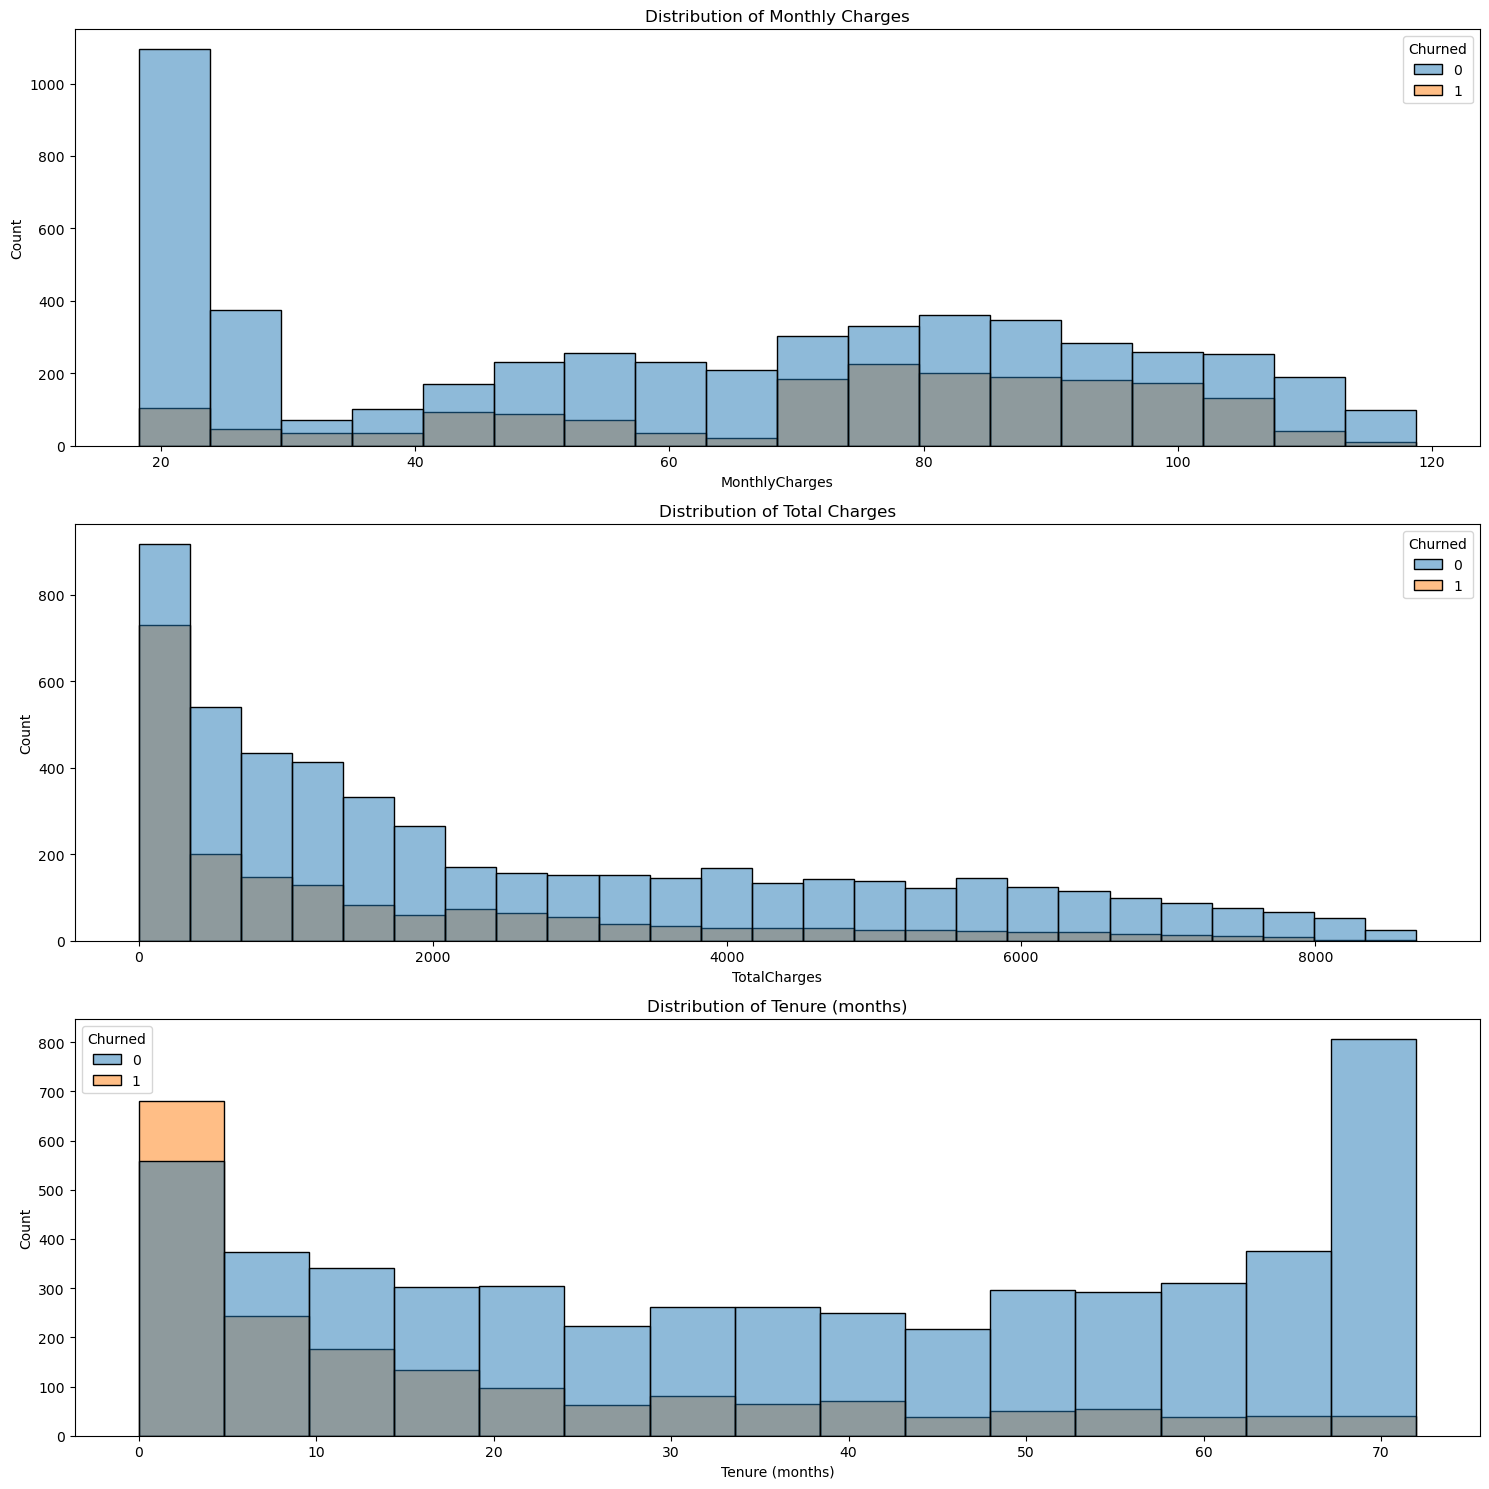

In [17]:
# Histogram for 'MonthlyCharges' with 'Churned' overlay
fig, axes = plt.subplots(3, 1, figsize=[15,15])
sns.histplot(data=df_final,
             x='MonthlyCharges',
             hue='Churned',
             ax=axes[0])
axes[0].set_title('Distribution of Monthly Charges')
sns.histplot(data=df_final,
             x='TotalCharges',
             hue='Churned',
             ax=axes[1])
axes[1].set_title('Distribution of Total Charges')
sns.histplot(data=df_final,
             x='Tenure (months)',
             hue='Churned',
             ax=axes[2])
axes[2].set_title('Distribution of Tenure (months)')
plt.tight_layout()
plt.show()


In [18]:
# Analyzing the Churn rate for categorical features
# Step A: get all object-dtype columns
categorical_cols = df_final.select_dtypes(include='object').columns

#Step B: drop columns with no meaningful information
categorical_cols = categorical_cols.drop(['customerID', 'EndDate'])

#Step C: Loop over remaining names, calling churn rate function on each
for col in categorical_cols:
    result = churn_rate_by_category(df_final, col)
    print(f"---{col}---")
    print(result)

---Type---
                 sum  count  churn_rate
Type                                   
Month-to-month  1655   3875      0.4271
One year         166   1473      0.1127
Two year          48   1695      0.0283
---PaperlessBilling---
                   sum  count  churn_rate
PaperlessBilling                         
No                 469   2872      0.1633
Yes               1400   4171      0.3357
---PaymentMethod---
                            sum  count  churn_rate
PaymentMethod                                     
Bank transfer (automatic)   258   1544      0.1671
Credit card (automatic)     232   1522      0.1524
Electronic check           1071   2365      0.4529
Mailed check                308   1612      0.1911
---gender---
        sum  count  churn_rate
gender                        
Female  939   3488      0.2692
Male    930   3555      0.2616
---Partner---
          sum  count  churn_rate
Partner                         
No       1200   3641      0.3296
Yes       669   3402  

### Contract Type Summary Conclusion

- Roughly a 15x difference in Churn Rate between 'Month-to-Month' & 'Two year' contracts
- 'Month-to-Month' contracts allow clients to leave at the end of any given month, where 'Two year' contracts lock a client into tougher process to leave in the middle of the contract.

### Senior Citizen Sumary

- A Senior Citizen is roughly 1.8x more likely to leave then a non-Senior Citizen

### Internet Service Summary
- Fiber Optic clients are over 5x as likely to churn than those without Interconnect's internet services.
- This is counter-intuitive since Fiber Optics is typically a premium service
- Begs the question: Is it a quality problem? Is it a pricing problem? Is it something else entirely?

### Multiple Lines Summary
- The spread here is less than 5 points
- This doesn't seem to have that large of an impact on the churn rate

### Payment Method Summary
- Electronic Check payment method is almost 3x higher than the other 3 payment methdods
- Begs the question: Is there a correlation between any of the other features with this payment method?

# Phase 3 - Target & Feature Engineering

In [19]:
# Derive 'HasInternet' column to show clients who have Internet Services
df_final['HasInternet'] = (df_final['InternetService'] != 'No Service').astype(int)

#print(df_final.head(20))
df_final['HasInternet'].value_counts()

HasInternet
1    5517
0    1526
Name: count, dtype: int64

In [20]:
# List of 6 columns linked ot 'HasInternet'
internet_services = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Loop over 6 columns and replace 'No Service' with 'No'
for i in internet_services:
    df_final[i] = df_final[i].replace('No Service', 'No')
    

In [21]:
# Derive 'HasPhone' column to show clients who have Phone Services
df_final['HasPhone'] = (df_final['MultipleLines'] != 'No Service').astype(int)

# Clean 'MultipleLines' column to only have 'Yes' or 'No' values
df_final['MultipleLines'] = df_final['MultipleLines'].replace('No Service', 'No')

df_final['MultipleLines'].value_counts()

MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64

In [22]:
# Using pd.get_dummies for 'PaymentMethod' feature
payment_dummies = pd.get_dummies(df_final['PaymentMethod'], prefix='PaymentMethod', drop_first=True)
payment_dummies = payment_dummies.astype(int)

df_final = pd.concat([df_final, payment_dummies], axis=1).drop(columns=['PaymentMethod'])

#print(df_final.head(10))

In [23]:
# Filtering out 'No Service' from 'InternetService' column for dummies creation
df_final['InternetService'] = df_final['InternetService'].replace('No Service', np.nan)

# Using pd.get_dummies for 'InternetService' feature
internet_dummies = pd.get_dummies(df_final['InternetService'], prefix='InternetService', drop_first=True, dummy_na=False)
internet_dummies = internet_dummies.astype(int)

df_final = pd.concat([df_final, internet_dummies], axis=1).drop(columns=['InternetService'])

#print(df_final.head(10))
#df_final.info()


In [24]:
# filter to verify that all dummies have been created and no 'No Service' values remain
df_final_filtered = df_final[df_final['HasInternet'] == 0]

#print(len(df_final))
#print(df_final_filtered.head(20))

In [25]:
# Using Ordinal Encoding for 'Type' feature
type_mapping = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_final['Type'] = df_final['Type'].map(type_mapping)

#df_final['Type'].value_counts()

In [26]:
# Using Ordinal Encoding for 'gender' feature
gender_mapping = {'Female': 0, 'Male': 1}
df_final['gender'] = df_final['gender'].map(gender_mapping)


In [27]:
# Looping through the categorical columns to create a binary mapping dictionary for each column
cat_col_list = ['PaperlessBilling', 'Partner', 'Dependents', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
cat_col_mapping = {'Yes': 1, 'No': 0}

for col in cat_col_list:
    df_final[col] = df_final[col].map(cat_col_mapping)


In [30]:
#df_final.info()

In [ ]:
# Building the features and target variable for the model
X = df_final.drop(columns=['customerID', 'BeginDate', 'EndDate', 'EndDate_dt', 'Churned'])
y = df_final['Churned']

# Phase 4 - Model Training

# Phase 5 - Evaluation